In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jsphyg/tipping")

print("Path to dataset files:", path)

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/anmnu/.cache/kagglehub/datasets/jsphyg/tipping/versions/1/tips.csv")


# Data Cleaning

## Checking missing values

In [5]:
df.isnull().sum() 

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

We have no missing values in our dataset

## Checking duplicate values

In [6]:
print("\nThe number of duplicated values in our dataset is", df.duplicated().sum())
df[df.duplicated(keep=False)]


The number of duplicated values in our dataset is 1


,total_bill,tip,sex,smoker,day,time,size
198,13.0,2.0,Female,Yes,Thur,Lunch,2
202,13.0,2.0,Female,Yes,Thur,Lunch,2


We both think that since we just have 1 duplicated value, it will not affect our analyses so we did not feel the need to remove it. 

## Checking the dimension, columns, and information regarding our dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [8]:
display(df)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [9]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


I am adding the tip percentage as an extra column for further EDA 

In [10]:
df["tip_percentage"] = (df["tip"]/df["total_bill"])*100

We now classify which variables are numerical and which ones are numerical

In [11]:
cat = df.select_dtypes(exclude="number")
num = df.select_dtypes(include="number")

In [12]:
cat

,sex,smoker,day,time
0,Female,No,Sun,Dinner
1,Male,No,Sun,Dinner
2,Male,No,Sun,Dinner
3,Male,No,Sun,Dinner
4,Female,No,Sun,Dinner
...,...,...,...,...
239,Male,No,Sat,Dinner
240,Female,Yes,Sat,Dinner
241,Male,Yes,Sat,Dinner
242,Male,No,Sat,Dinner


For categorical columns, we have sex (male or female), smoker status (a smoker or non-smoker), day of the weeks (Thursday, Friday, Saturday, Sunday), time (lunch or dinner)

In [13]:
num

,total_bill,tip,size,tip_percentage
0,16.99,1.01,2,5.944673
1,10.34,1.66,3,16.054159
2,21.01,3.50,3,16.658734
3,23.68,3.31,2,13.978041
4,24.59,3.61,4,14.680765
...,...,...,...,...
239,29.03,5.92,3,20.392697
240,27.18,2.00,2,7.358352
241,22.67,2.00,2,8.822232
242,17.82,1.75,2,9.820426


For numerical columns, we have total bill (in dollars), tip amount (in dollars), party size (1, 2, 3, 4, 5, 6 people), and the added one, tip percentage (%)

# Explotarory Data Analysis (EDA)

### 1. What is the typical amount people spend on a meal? Is the "average" bill very different from the "middle" (median) bill?(univariate).


The mean of the total bill is 19.78594262295082

The median of the total bill is 17.795


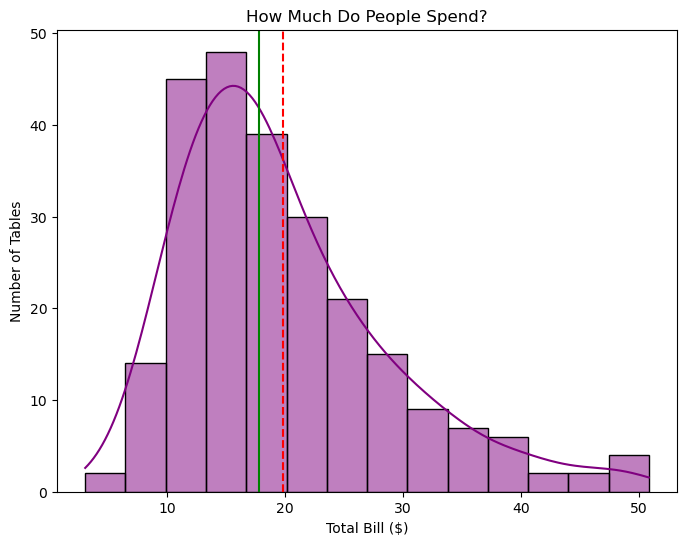

In [3]:
print("\nThe mean of the total bill is", df['total_bill'].mean())
print("\nThe median of the total bill is", df['total_bill'].median())

average = df['total_bill'].mean()
middle = df['total_bill'].median()
plt.figure(figsize=(8, 6))
sns.histplot(df['total_bill'], kde=True, color='purple')
plt.axvline(average, color='red', linestyle='--', label=f'Mean: ${average:.2f}')
plt.axvline(middle, color='green', linestyle='-', label=f'Median: ${middle:.2f}')
plt.title('How Much Do People Spend?')
plt.xlabel('Total Bill ($)')
plt.ylabel('Number of Tables')
plt.show()

Analysis: The "typical" amount is best represented by the middle (around $17.79), as it isn't affected by those rare $50+ bills and the mean is roughly $2 higher than the median.

### 2. What are the most popular size of dining guests? (univariate)

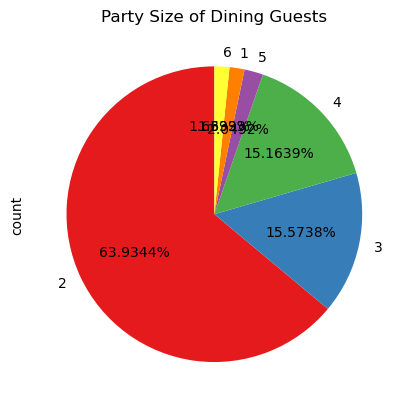

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\3666176619.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="size", data=df, palette='viridis', legend=False)


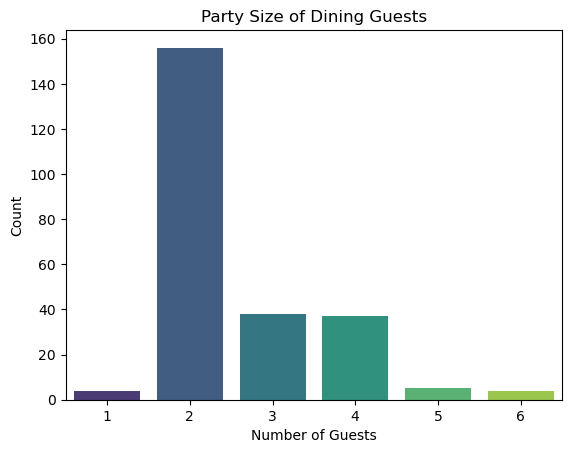

In [4]:
groupsize = df["size"].value_counts()
groupsize.plot.pie(autopct='%1.4f%%' ,startangle=90, colors=sns.color_palette('Set1'))
plt.title('Party Size of Dining Guests')
plt.show()

sns.countplot(x="size", data=df, palette='viridis', legend=False)
plt.title('Party Size of Dining Guests')
plt.xlabel('Number of Guests')
plt.ylabel('Count')
plt.show()

Observation: The overwhelming majority of the dining guest come in pairs (very likely couples), follwed by a group of 3 and 4. Alone diners and a bigger party size of 5 and 6 are rare, which makes up less than 10%. 


### 3. What are the most popular days to dine in the restaurant? (univariate)

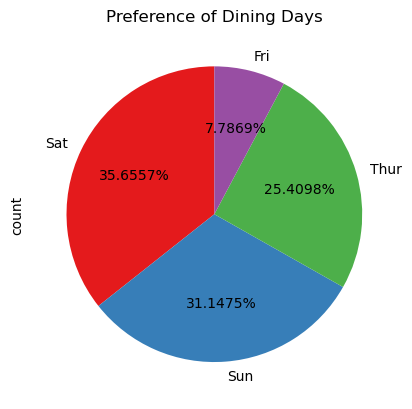

C:\Users\anmnu\AppData\Local\Temp\ipykernel_25540\2566573441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="day", data=df, palette='viridis', legend=False)


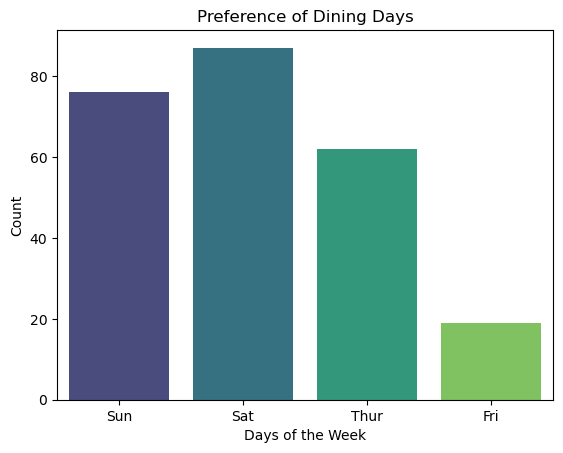

In [4]:
diningdays = df["day"].value_counts()
diningdays
diningdays.plot.pie(autopct='%1.4f%%' ,startangle=90, colors=sns.color_palette('Set1'))
plt.title('Preference of Dining Days')
plt.show()

sns.countplot(x="day", data=df, palette='viridis', legend=False)
plt.title('Preference of Dining Days')
plt.xlabel('Days of the Week')
plt.ylabel('Count')
plt.show()

Observation: Here we found out that a majority of dining guests came on weekends (68% in total)

### 4. Do people tend to spend more money during lunch or during dinner? 

time
Dinner    20.797159
Lunch     17.168676
Name: total_bill, dtype: float64

C:\Users\anmnu\AppData\Local\Temp\ipykernel_25540\2069119554.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='time', y='total_bill', data=df, palette='Set2')


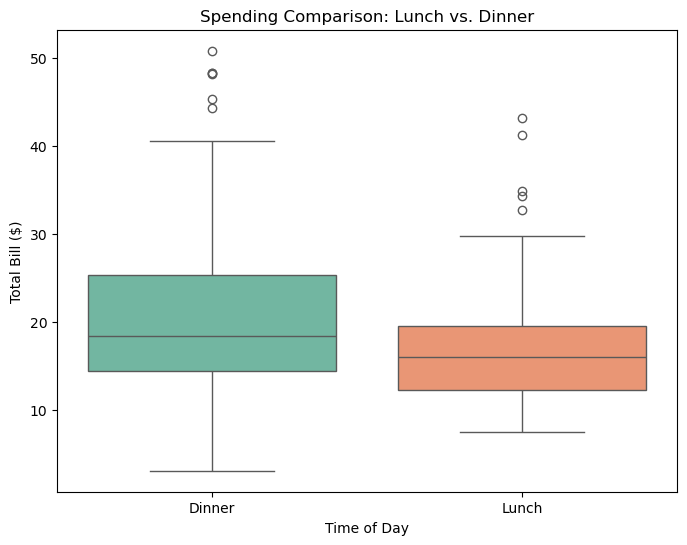

In [9]:
display((df.groupby('time')['total_bill'].mean()))

plt.figure(figsize=(8, 6))
sns.boxplot(x='time', y='total_bill', data=df, palette='Set2')
plt.title('Spending Comparison: Lunch vs. Dinner')
plt.xlabel('Time of Day')
plt.ylabel('Total Bill ($)')
plt.show()

Observation: The median line in the Dinner boxplot sits significantly higher than the Lunch median, Dinner is consistently more expensive. You will likely see more "dots" above the dinner whiskers. These represent the rare, very expensive tables that almost never happen during lunch. The Interquartile Range (IQR) for Dinner is much wider than for Lunch.

### 5. Is there a difference in the average bill amount between parties that have smokers and those that don't?

smoker
No     19.188278
Yes    20.756344
Name: total_bill, dtype: float64

C:\Users\anmnu\AppData\Local\Temp\ipykernel_25540\3849285722.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='smoker', y='total_bill', data=df, palette='Set1')


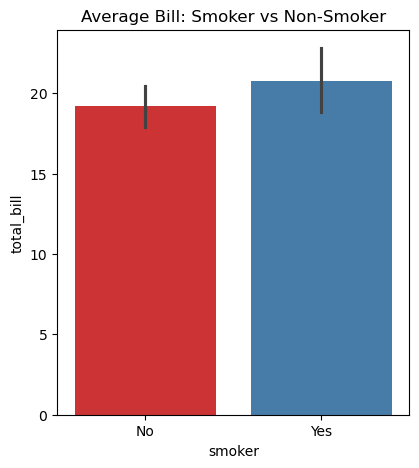

C:\Users\anmnu\AppData\Local\Temp\ipykernel_25540\3849285722.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='smoker', y='total_bill', data=df, palette='Set1')


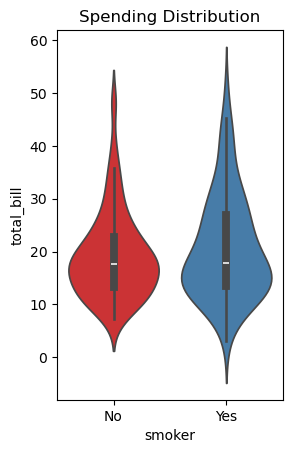

In [11]:
display(df.groupby('smoker')['total_bill'].mean())

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='smoker', y='total_bill', data=df, palette='Set1')
plt.title('Average Bill: Smoker vs Non-Smoker')
plt.show()
#VISUALISE DISTRIBUTION VIA VIOLINPLOT:
plt.subplot(1, 2, 2)
sns.violinplot(x='smoker', y='total_bill', data=df, palette='Set1')
plt.title('Spending Distribution')
plt.show()

Observation: Typically, smokers have a slightly higher average bill compared to non-smokers. However, the difference isn't massive. If you look at the Violin Plot, you'll notice the "smoker" side is often wider at the top or has longer thin lines. Smokers: Their spending is more "erratic." They have more extreme low bills and extreme high bills. Non-Smokers: Their spending is more "stable" and consistent.

### 6. How strong is the correlation between the total_bill and the tip? Can we see any specific clusters where people spend a lot but tip very little (or vice versa)?

np.float64(0.6757341092113641)

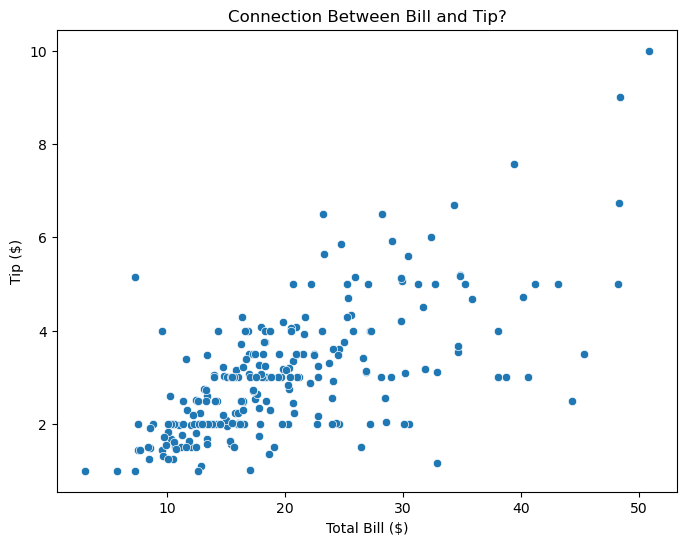

In [12]:
correlation = df['total_bill'].corr(df['tip'])
display(correlation)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["total_bill"], y=df["tip"])
plt.title('Connection Between Bill and Tip?')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

Observation: This is considered as a strong positive correlation. As the total bill increases, the tip generally increases as well. It tells us that customers usually follow the "percentage rule" (tipping based on the cost of the meal) rather than leaving a flat amount.

### 7. Are there any extreme outliers in the tip or total_bill columns? What are the characteristics (day, time, size) of the top 5% of highest tips?

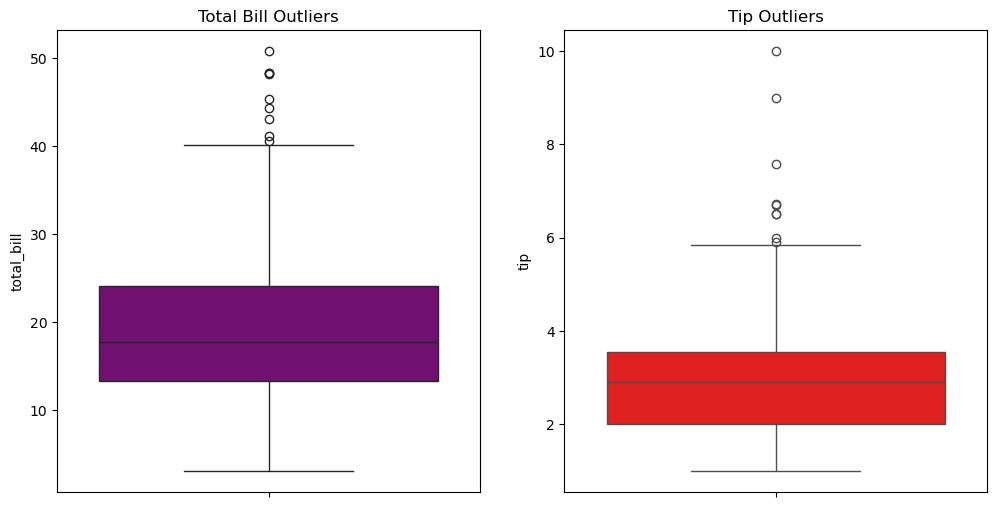

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['total_bill'], color='purple')
plt.title('Total Bill Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['tip'], color='red')
plt.title('Tip Outliers')
plt.show()



Observation: Total Bill: There are several extreme bills over $40, with the highest nearing $50. Tips: There is a clear "super outlier" at $10. Most tips stop around $6, making that $10 tip a significant anomaly.

### 8. Is there a correlation between party size and sex? Correlation between smoker status and party size?

C:\Users\anmnu\AppData\Local\Temp\ipykernel_25540\3878948273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sex", y="size", palette="coolwarm", legend=True)


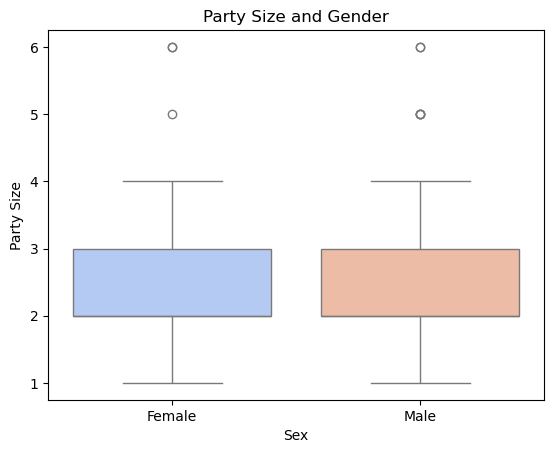

C:\Users\anmnu\AppData\Local\Temp\ipykernel_25540\3878948273.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="sex", y="size", palette="coolwarm", errorbar=None, estimator = "mean")


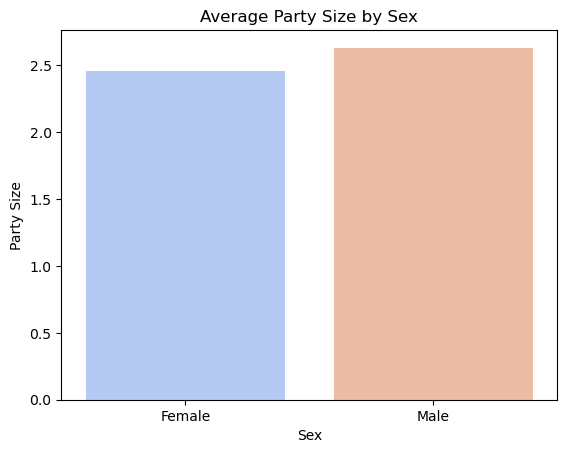

C:\Users\anmnu\AppData\Local\Temp\ipykernel_25540\3878948273.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="sex", y="size", palette="coolwarm", errorbar=None, estimator = "max")


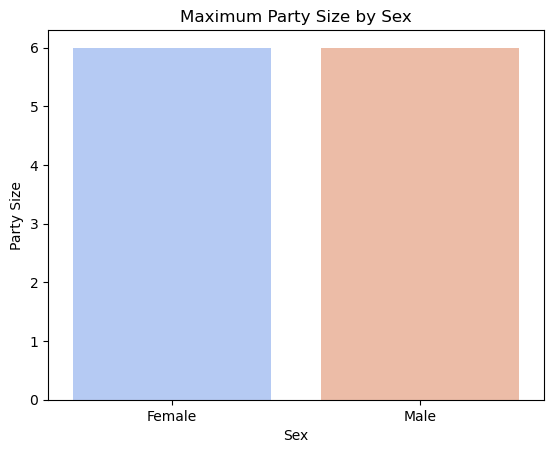

In [14]:
# we can groupby (subgroups) of party size 1-2 (small) and more (3-6)
# I think we can emphasize the importance of really looking at univariate 

sns.boxplot(data=df, x="sex", y="size", palette="coolwarm", legend=True)
plt.title('Party Size and Gender')
plt.xlabel('Sex')
plt.ylabel('Party Size')
plt.show()

sns.barplot(data=df, x="sex", y="size", palette="coolwarm", errorbar=None, estimator = "mean")  
plt.title('Average Party Size by Sex')
plt.xlabel('Sex')
plt.ylabel('Party Size')
plt.show()

sns.barplot(data=df, x="sex", y="size", palette="coolwarm", errorbar=None, estimator = "max")  
plt.title('Maximum Party Size by Sex')
plt.xlabel('Sex')
plt.ylabel('Party Size')
plt.show()

In [16]:
crosstab_result_1 = pd.crosstab(df['sex'], df['size'])
crosstab_result_1

size,1,2,3,4,5,6
sex,,,,,,
Female,3,58,14,9,1,2
Male,1,98,24,28,4,2


Observation for party size and sex: Both sexes have very similar medians Males have a slightly higher average party size. Both have some larger party outliers. 

C:\Users\anmnu\AppData\Local\Temp\ipykernel_25540\4138881422.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="smoker", y="size", palette="coolwarm", legend=True)


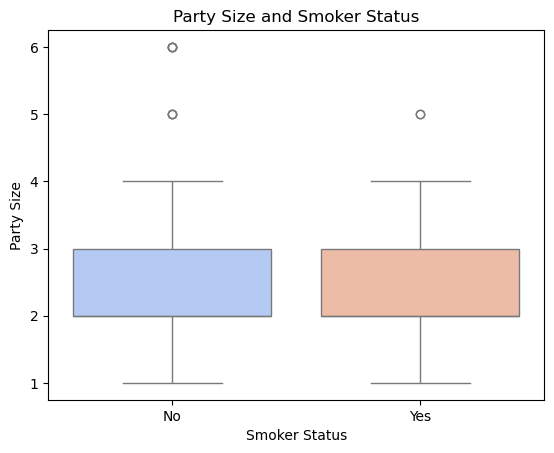

C:\Users\anmnu\AppData\Local\Temp\ipykernel_25540\4138881422.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="smoker", y="size", palette="coolwarm", errorbar=None, estimator = "mean")


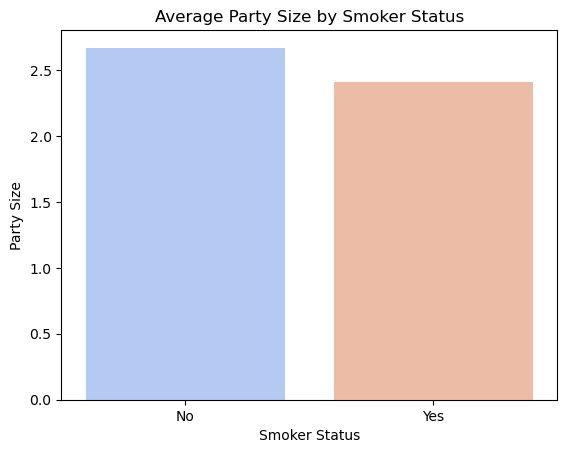

C:\Users\anmnu\AppData\Local\Temp\ipykernel_25540\4138881422.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="smoker", y="size", palette="coolwarm", errorbar=None, estimator = "max")


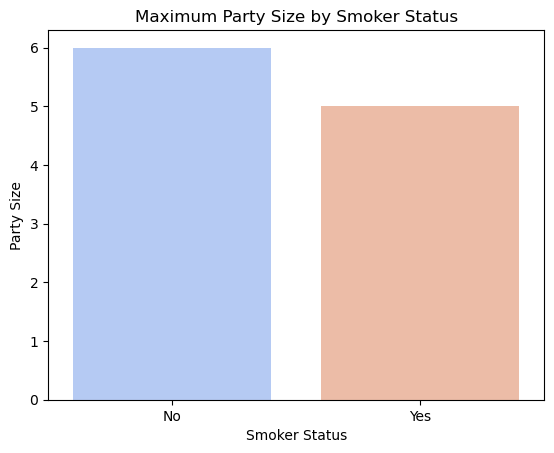

In [17]:
sns.boxplot(data=df, x="smoker", y="size", palette="coolwarm", legend=True)
plt.title('Party Size and Smoker Status')
plt.xlabel('Smoker Status')
plt.ylabel('Party Size')
plt.show()

sns.barplot(data=df, x="smoker", y="size", palette="coolwarm", errorbar=None, estimator = "mean")  
plt.title('Average Party Size by Smoker Status')
plt.xlabel('Smoker Status')
plt.ylabel('Party Size')
plt.show()

sns.barplot(data=df, x="smoker", y="size", palette="coolwarm", errorbar=None, estimator = "max")  
plt.title('Maximum Party Size by Smoker Status')
plt.xlabel('Smoker Status')
plt.ylabel('Party Size')
plt.show()

In [14]:
crosstab_result_2 = pd.crosstab(df['smoker'], df['size'])
crosstab_result_2

size,1,2,3,4,5,6
smoker,,,,,,
No,2,90,26,26,3,4
Yes,2,66,12,11,2,0


Observation for party size and smoker status: There does not seem to be a strong relationship between party size and smoker status. Both smokers and nonsmokers have similar average party size, while the maximum party size for smoker is 5 and for nonsmokers 6, this difference is minor. 

### 9. What patterns can be found in tip percentage across different days and meal times?

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\1000864632.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="day", y="tip_percentage", palette="coolwarm", legend=True)


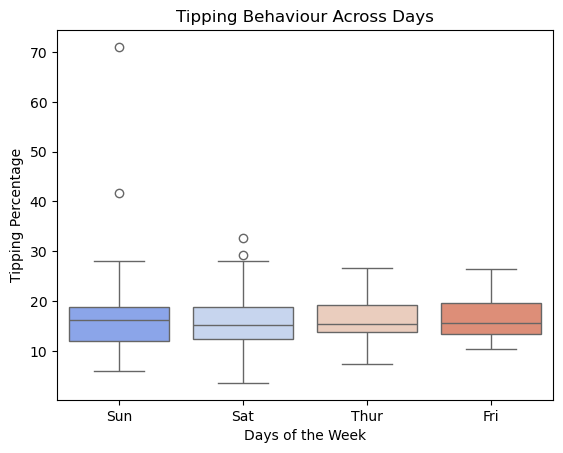

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\1000864632.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="day", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "mean")


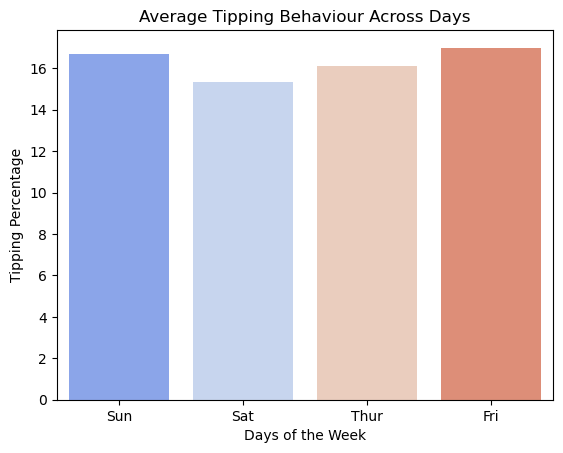

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\1000864632.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="day", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "max")


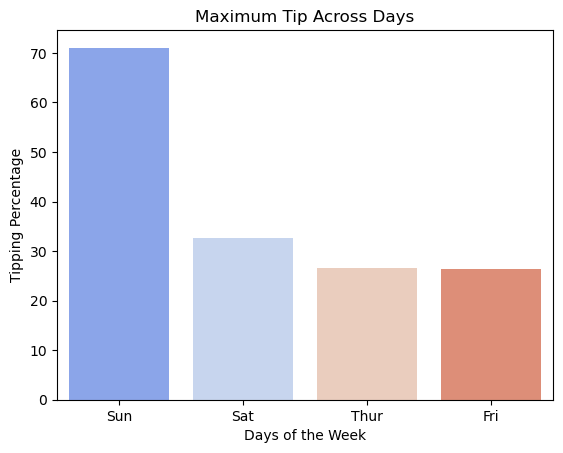

In [15]:
sns.boxplot(data=df, x="day", y="tip_percentage", palette="coolwarm", legend=True)
plt.title('Tipping Behaviour Across Days')
plt.xlabel('Days of the Week')
plt.ylabel('Tipping Percentage')
plt.show()

sns.barplot(data=df, x="day", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "mean")  
plt.title('Average Tipping Behaviour Across Days')
plt.xlabel('Days of the Week')
plt.ylabel('Tipping Percentage')
plt.show()

sns.barplot(data=df, x="day", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "max")  
plt.title('Maximum Tip Across Days')
plt.xlabel('Days of the Week')
plt.ylabel('Tipping Percentage')
plt.show()

Observation: Tipping behaviour across different days show no big differences, as the average tipping percentage across the 4 days are between 14 to 16. Notable generous tippers however were observed on Sunday, with one tipping 70% and on 40%. 

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\4007297109.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="time", y="tip_percentage", palette="coolwarm", legend=True)


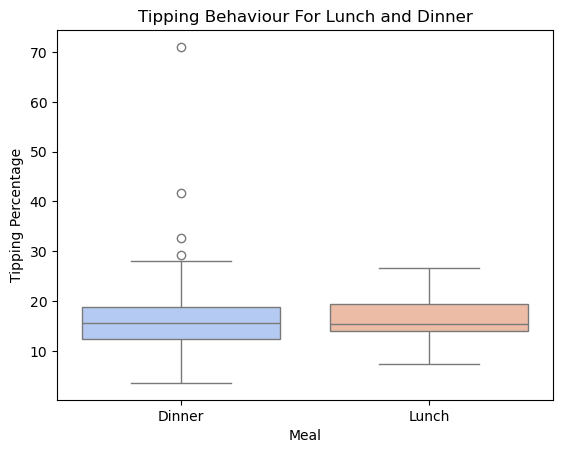

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\4007297109.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="time", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "mean")


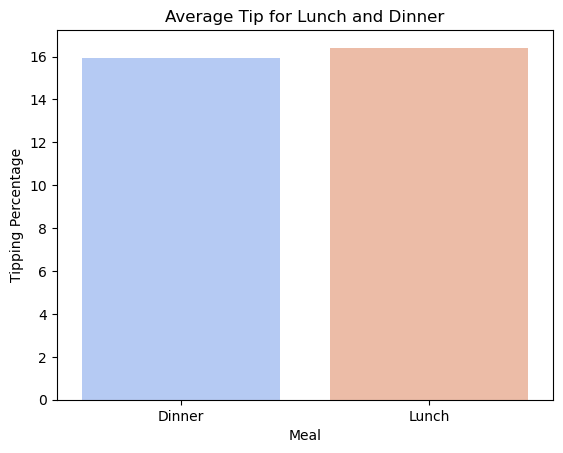

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\4007297109.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="time", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "max")


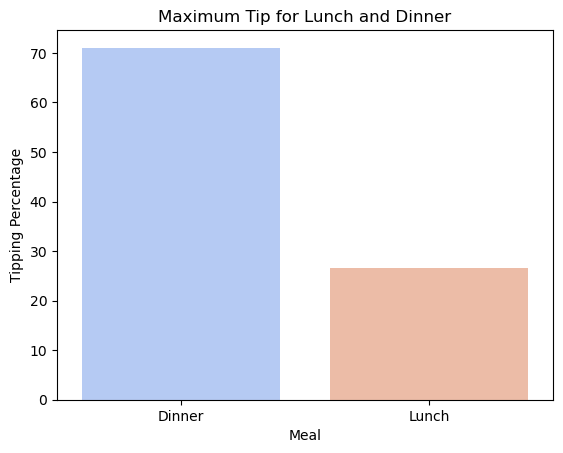

In [16]:
sns.boxplot(data=df, x="time", y="tip_percentage", palette="coolwarm", legend=True)
plt.title('Tipping Behaviour For Lunch and Dinner')
plt.xlabel('Meal')
plt.ylabel('Tipping Percentage')
plt.show()

sns.barplot(data=df, x="time", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "mean")  
plt.title('Average Tip for Lunch and Dinner')
plt.xlabel('Meal')
plt.ylabel('Tipping Percentage')
plt.show()

sns.barplot(data=df, x="time", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "max")  
plt.title('Maximum Tip for Lunch and Dinner')
plt.xlabel('Meal')
plt.ylabel('Tipping Percentage')
plt.show()

Observation: With regards to lunch and dinner (differnet meal types), we observed a similar tipping behaviour, with the majority around 15%. Notable generous tippers are observed for dinner, with 3 tips above 30%. 

### 10. What is the impact of party size or smoker status on tipping behaviour?

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\2757851102.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="size", y="tip_percentage", palette="coolwarm", legend=True)


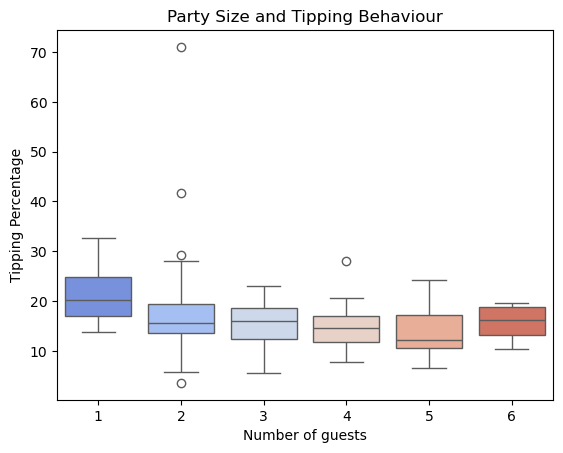

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\2757851102.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="size", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "mean")


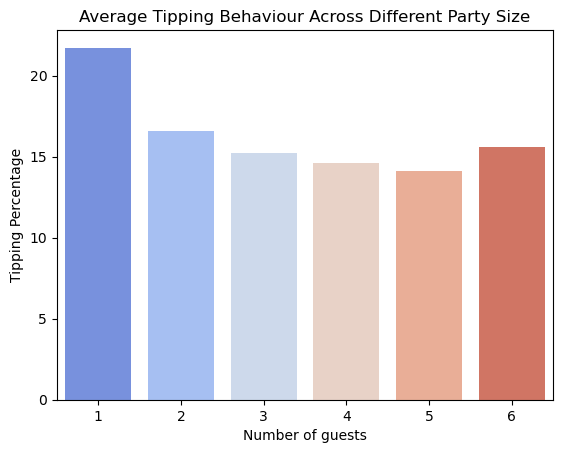

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\2757851102.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="size", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "max")


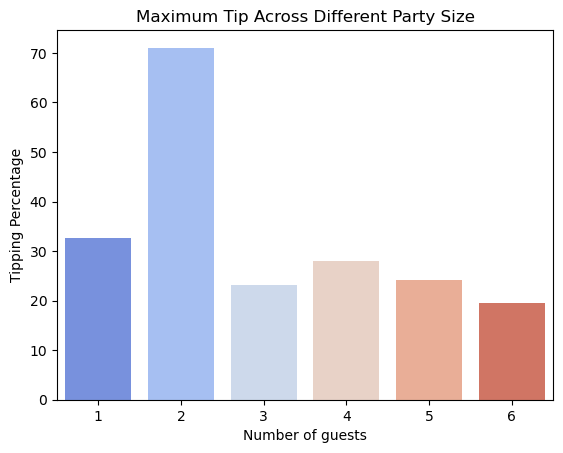

In [18]:
sns.boxplot(data=df, x="size", y="tip_percentage", palette="coolwarm", legend=True)
plt.title('Party Size and Tipping Behaviour')
plt.xlabel('Number of guests')
plt.ylabel('Tipping Percentage')
plt.show()

sns.barplot(data=df, x="size", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "mean")  
plt.title('Average Tipping Behaviour Across Different Party Size')
plt.xlabel('Number of guests')
plt.ylabel('Tipping Percentage')
plt.show()

sns.barplot(data=df, x="size", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "max")  
plt.title('Maximum Tip Across Different Party Size')
plt.xlabel('Number of guests')
plt.ylabel('Tipping Percentage')
plt.show()

Observation: We can see that those who dine alone generally tip better (20% tipping average) compared to those who do not dine alone (around 15%). Party of 2 saw 3 outliers on the higher end, meaning that we have 3 tips from party of 2 that tip above 30%.

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\1054515202.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="smoker", y="tip_percentage", palette="coolwarm", legend=True)


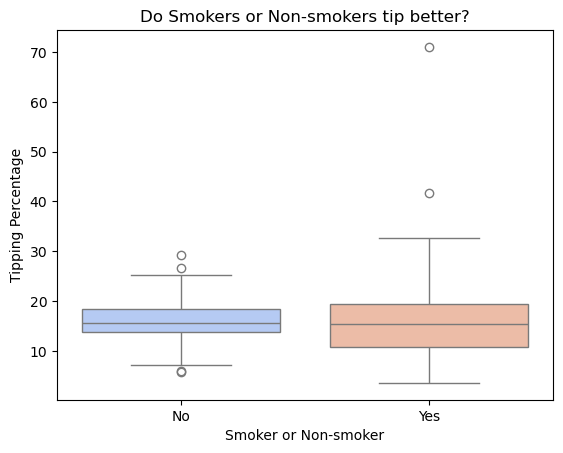

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\1054515202.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="smoker", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "mean")


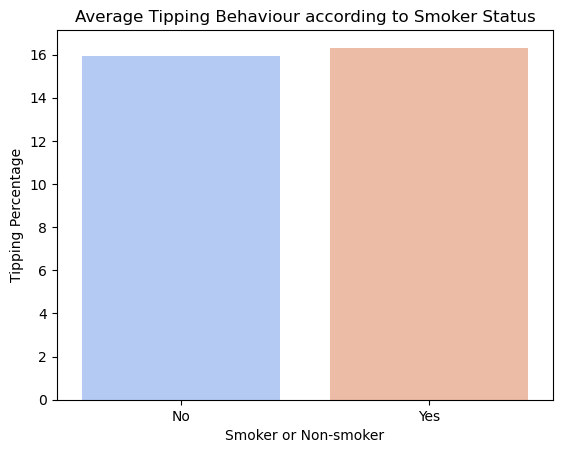

C:\Users\anmnu\AppData\Local\Temp\ipykernel_20188\1054515202.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="smoker", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "max")


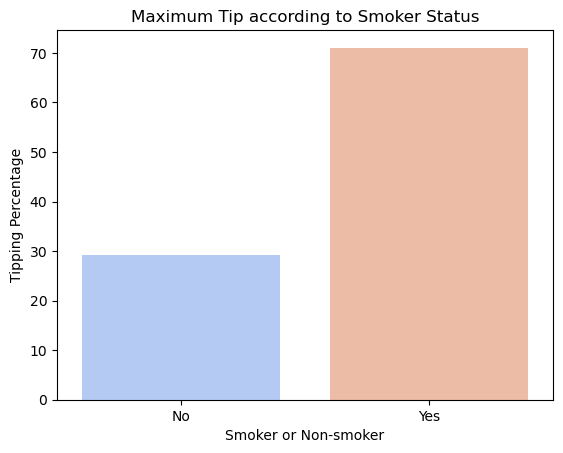

In [19]:
sns.boxplot(data=df, x="smoker", y="tip_percentage", palette="coolwarm", legend=True)
plt.title('Do Smokers or Non-smokers tip better?')
plt.xlabel('Smoker or Non-smoker')
plt.ylabel('Tipping Percentage')
plt.show()

sns.barplot(data=df, x="smoker", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "mean")  
plt.title('Average Tipping Behaviour according to Smoker Status')
plt.xlabel('Smoker or Non-smoker')
plt.ylabel('Tipping Percentage')
plt.show()

sns.barplot(data=df, x="smoker", y="tip_percentage", palette="coolwarm", errorbar=None, estimator = "max")  
plt.title('Maximum Tip according to Smoker Status')
plt.xlabel('Smoker or Non-smoker')
plt.ylabel('Tipping Percentage')
plt.show()

Observation: Smoker and nonsmoker generally tip the same amount around 15%. However, our 2 largest tips come from smokers. 